# SETTTINGS

In [34]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
# DataSet
dataset = "ddos_multiclass.csv"

# Outliers Switch & Proportion
remove_outliers = False
outlier_proportion = 1.5

# Feature Selection Embedded
rf_feature_embedded = False

# Columns to Drop
columns_to_drop = ['Unnamed: 0', 'Flow ID', 'Timestamp','Source IP', 'Destination IP', 'SimillarHTTP']

# Target Variable Assignment
target_name = 'Label'

# Data Types & Conversion
data_types = {0:'int32', 1:'int64', 2:'float32', 3:'float64', 4:'str', 5:'object'}
features_to_convert = {'Flow Bytes/s':data_types[1]}

# Model Name
pickle_name = "ddos_multi_classify_model"

<hr style='height:10px'>

<br id='basic'>

## BASIC LIBRARIES

* <b>Numpy</b> - Numerical Analysis Library
* <b>Pandas</b> - For Data Load, Exploratory Data Analysis and Data Preprocessing 
* <b>Matplotlib</b> - For Charts or Plots
* <b>Seaborn</b> - for Charts or Plots built on top of Matplotlib


In [36]:
# Numpy
import numpy as np

# Pandas
import pandas as pd

# Matplotlib
import matplotlib.pyplot as plt

# Seaborn
import seaborn as sns

from scipy.stats import skew

import statistics as st

In [37]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

<hr style='height:10px'>

<br id='preparation'>

## DATA PREPARATION

In [38]:
df = pd.read_csv('./data/'+dataset)

## Strip Trail Spacesin Column Names

In [39]:
df.columns = [col.strip() for col in df.columns]

In [40]:
df.dtypes

Unnamed: 0.1                     int64
Unnamed: 0                       int64
Flow ID                         object
Source IP                       object
Source Port                      int64
Destination IP                  object
Destination Port                 int64
Protocol                         int64
Timestamp                       object
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets    float64
Total Length of Bwd Packets    float64
Fwd Packet Length Max          float64
Fwd Packet Length Min          float64
Fwd Packet Length Mean         float64
Fwd Packet Length Std          float64
Bwd Packet Length Max          float64
Bwd Packet Length Min          float64
Bwd Packet Length Mean         float64
Bwd Packet Length Std          float64
Flow Bytes/s                   float64
Flow Packets/s                 float64
Flow IAT Mean                  float64
Flow IAT Std             

<hr style='height:10px'>

<br id='eda'>

## EXPLORATORY DATA ANALYSIS

<br id='shape'>

#### DataFrame Shape

In [41]:
df.shape   # (rows, columns)

(22000, 89)

<br id='head'>

#### First 5 Rows

In [42]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,2011980,27112,172.16.0.5-192.168.50.1-611-55433-17,172.16.0.5,611,192.168.50.1,55433,17,2018-12-01 11:31:42.099511,2,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,1.472000e+09,1000000.0,2.0,0.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,-2,0,1000000.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,-2,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_LDAP
1,1115664,31333,172.16.0.5-192.168.50.1-813-18183-17,172.16.0.5,813,192.168.50.1,18183,17,2018-12-01 11:27:33.766335,2,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,1.472000e+09,1000000.0,2.0,0.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,40,0,1000000.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,40,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_LDAP
2,882627,12241,172.16.0.5-192.168.50.1-533-22175-17,172.16.0.5,533,192.168.50.1,22175,17,2018-12-01 11:26:32.033962,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,2.944000e+09,2000000.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,28,0,2000000.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,28,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_LDAP
3,2121311,26527,172.16.0.5-192.168.50.1-747-49557-17,172.16.0.5,747,192.168.50.1,49557,17,2018-12-01 11:32:15.157093,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,2.944000e+09,2000000.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,-2,0,2000000.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,-2,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_LDAP
4,926335,6874,172.16.0.5-192.168.50.1-849-53174-17,172.16.0.5,849,192.168.50.1,53174,17,2018-12-01 11:26:43.635745,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,2.944000e+09,2000000.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,2000000.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,0,0,0,0,0,0,0,2,2944,0,0,-1,-1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_LDAP


<br id='tail'>

#### Last 5 Rows

In [43]:
df.tail()

,Unnamed: 0.1,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
21995,268835,132887,172.16.0.5-192.168.50.1-32984-16498-6,172.16.0.5,32984,192.168.50.1,16498,6,2018-12-01 13:30:13.172392,1,2,0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,2.000000e+06,1.0,0.000000,1.0,1.0,1.0,1.0,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,40,0,2.000000e+06,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0,40,0,0,0,0,0,0,2,0,0,0,5840,-1,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag
21996,91444,347081,172.16.0.5-192.168.50.1-25981-32492-6,172.16.0.5,25981,192.168.50.1,32492,6,2018-12-01 13:29:47.296582,1,2,0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,2.000000e+06,1.0,0.000000,1.0,1.0,1.0,1.0,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,40,0,2.000000e+06,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0,40,0,0,0,0,0,0,2,0,0,0,5840,-1,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag
21997,347432,10687,172.16.0.5-192.168.50.1-43039-25141-6,172.16.0.5,43039,192.168.50.1,25141,6,2018-12-01 13:30:26.884583,1,2,0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,2.000000e+06,1.0,0.000000,1.0,1.0,1.0,1.0,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,40,0,2.000000e+06,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0,40,0,0,0,0,0,0,2,0,0,0,5840,-1,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag
21998,31021,142687,172.16.0.5-192.168.50.1-53318-39580-17,172.16.0.5,53318,192.168.50.1,39580,17,2018-12-01 13:04:52.315215,212881,6,0,2088.0,0.0,393.0,321.0,348.0,35.08846,0.0,0.0,0.0,0.0,9808.296654,2.818476e+01,42576.2,58322.876615,108867.0,1.0,212881.0,42576.2,58322.876615,108867.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,48,0,2.818476e+01,0.0,321.0,393.0,344.142857,33.617597,1130.142857,0,0,0,0,0,0,0,0,0.0,401.5,348.0,0.0,48,0,0,0,0,0,0,6,2088,0,0,-1,-1,5,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag
21999,239688,309259,172.16.0.5-192.168.50.1-5875-28236-6,172.16.0.5,5875,192.168.50.1,28236,6,2018-12-01 13:30:08.162669,1,2,0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,2.000000e+06,1.0,0.000000,1.0,1.0,1.0,1.0,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,40,0,2.000000e+06,0.0,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0,40,0,0,0,0,0,0,2,0,0,0,5840,-1,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,UDP-lag


<br id='freq'>

#### Target Variable - Frequency

In [44]:
df[target_name].value_counts()

Label
DrDoS_MSSQL      2000
DrDoS_SNMP       2000
DrDoS_SSDP       2000
DrDoS_LDAP       1999
DrDoS_NetBIOS    1999
DrDoS_UDP        1999
DrDoS_DNS        1998
Syn              1998
TFTP             1997
UDP-lag          1986
DrDoS_NTP        1985
BENIGN             37
WebDDoS             2
Name: count, dtype: int64

<br id='dtypes'>

#### DataTypes

In [45]:
df.dtypes

Unnamed: 0.1                     int64
Unnamed: 0                       int64
Flow ID                         object
Source IP                       object
Source Port                      int64
Destination IP                  object
Destination Port                 int64
Protocol                         int64
Timestamp                       object
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets    float64
Total Length of Bwd Packets    float64
Fwd Packet Length Max          float64
Fwd Packet Length Min          float64
Fwd Packet Length Mean         float64
Fwd Packet Length Std          float64
Bwd Packet Length Max          float64
Bwd Packet Length Min          float64
Bwd Packet Length Mean         float64
Bwd Packet Length Std          float64
Flow Bytes/s                   float64
Flow Packets/s                 float64
Flow IAT Mean                  float64
Flow IAT Std             

<br id='cat'>

#### Categorical Features

In [46]:
cat_features = df.dtypes[df.dtypes == 'object'].index

<br id='catstat'>

#### Summary Statistics of all Categorical Fetures

* We have used Pandas describe method on all the Numerical Features to understand Statistical Information like - 
    
        1. Max
        2. Min

In [47]:
# Summarize categorical features
df[cat_features].describe()

,Flow ID,Source IP,Destination IP,Timestamp,SimillarHTTP,Label
count,22000,22000,22000,22000,22000,22000
unique,21993,9,22,22000,5,13
top,172.16.0.5-192.168.50.1-672-40868-17,172.16.0.5,192.168.50.1,2018-12-01 11:31:42.099511,0,DrDoS_MSSQL
freq,2,21950,21950,1,13804,2000


<br id='num'>

###  Numerical Features

In [48]:
for features in df.dtypes[df.dtypes != 'object'].index:
    print(features)

Unnamed: 0.1
Unnamed: 0
Source Port
Destination Port
Protocol
Flow Duration
Total Fwd Packets
Total Backward Packets
Total Length of Fwd Packets
Total Length of Bwd Packets
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min
Fwd PSH Flags
Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
Fwd Header Length
Bwd Header Length
Fwd Packets/s
Bwd Packets/s
Min Packet Length
Max Packet Length
Packet Length Mean
Packet Length Std
Packet Length Variance
FIN Flag Count
SYN Flag Count
RST Flag Count
PSH Flag Count
ACK Flag Count
URG Flag Count
CWE Flag Count
ECE Flag Count
Down/Up Ratio
Average Packet Size
Avg Fwd Segment Size
Avg Bwd Segment Size
Fwd Header Length.1
Fwd Avg By

<br id='numstat'>

### Summary Statistics of all Numerical Fetures

* We have used Pandas describe method on all the Numerical Features to understand Statistical Information like - 
    
        1. Mean
        2. Standard Deviation
        3. Max
        4. Min
        5. 25th Percentile
        6. 50th Percentile
        7. 75th Percentile

In [49]:
num_features = df.dtypes[df.dtypes != 'object'].index

In [50]:
# Summarize numerical features
df[num_features].describe()

,Unnamed: 0.1,Unnamed: 0,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound
count,2.200000e+04,22000.000000,22000.000000,22000.000000,22000.000000,2.200000e+04,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,2.157800e+04,2.200000e+04,2.200000e+04,2.200000e+04,2.200000e+04,22000.000000,2.200000e+04,2.200000e+04,2.200000e+04,2.200000e+04,22000.000000,2.200000e+04,2.200000e+04,2.200000e+04,2.200000e+04,22000.000000,22000.000000,22000.0,22000.0,22000.0,2.200000e+04,22000.000000,2.200000e+04,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.0,22000.000000,22000.000000,22000.0,22000.000000,22000.000000,22000.000000,22000.0,22000.000000,22000.000000,22000.000000,22000.000000,2.200000e+04,22000.0,22000.0,22000.0,22000.0,22000.0,22000.0,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,2.200000e+04,2.200000e+04,2.200000e+04,2.200000e+04,2.200000e+04,2.200000e+04,2.200000e+04,2.200000e+04,2.200000e+04,22000.000000
mean,2.286761e+06,96995.076318,24369.699909,32829.002136,15.103727,1.499051e+06,8.235227,0.070545,3878.450182,10.261182,623.114909,609.220045,618.732203,5.414138,0.860909,0.073136,0.264410,0.259707,inf,inf,2.153970e+05,3.331477e+05,7.130218e+05,4.838273,1.497591e+06,2.283199e+05,3.403615e+05,7.120458e+05,4.811682,9.116170e+04,1.913813e+04,3.279541e+04,6.539420e+04,0.110409,0.000273,0.0,0.0,0.0,-1.150150e+08,1.464727,1.092838e+06,420.915986,609.220000,623.505227,618.491190,5.340082,468.030912,0.0,0.000045,0.000273,0.0,0.171136,0.001136,0.000818,0.0,0.018000,894.399048,618.732203,0.264410,-1.150150e+08,0.0,0.0,0.0,0.0,0.0,0.0,8.235227,3878.450182,0.070545,10.261182,1019.159091,13.173727,6.903364,-3.734002e+07,8.441618e+02,7.717968e+02,1.918579e+03,4.213696e+02,4.478290e+05,9.426985e+04,5.569739e+05,3.646286e+05,0.997955
std,3.274598e+06,138189.967180,24827.655510,18817.189733,4.155547,9.699090e+06,26.154688,1.219948,11459.075745,839.371335,535.892856,542.847325,537.368645,19.149823,45.199090,3.170470,12.463600,14.502649,NaN,NaN,1.077937e+06,1.645541e+06,3.762869e+06,16.734899,9.698768e+06,1.148347e+06,1.691090e+06,3.762609e+06,15.080298,2.509245e+06,5.225811e+05,8.843177e+05,1.726678e+06,2.085634,0.016513,0.0,0.0,0.0,2.045599e+09,25.124497,9.092737e+05,6408.994860,542.847376,536.563536,537.473084,20.965076,10691.816521,0.0,0.006742,0.016513,0.0,0.376637,0.033692,0.028593,0.0,0.144111,820.466739,537.368645,12.463600,2.045599e+09,0.0,0.0,0.0,0.0,0.0,0.0,26.154688,11459.075745,1.219948,839.371335,2476.190416,774.911039,26.197551,1.956770e+08,4.381715e+04,3.211204e+04,7.151644e+04,3.922403e+04,2.

<br id='cat'>

### List of Categorical Features in DataFrame

In [51]:
df.dtypes[df.dtypes=='object']

Flow ID           object
Source IP         object
Destination IP    object
Timestamp         object
SimillarHTTP      object
Label             object
dtype: object

<hr style='height:10px'>

<br id='neg'>

### Replace Negative Values with Zero

* Replaced Negative Values as Multinomial Naive Bayes and related Algorithms doesn't accept Negative Values

In [52]:
num = df._get_numeric_data()

num[num < 0] = 0

<br id='unnec'>

### Remove Unnecessary Features

In [53]:
df = df.drop(columns_to_drop, axis=1)

<br id='dropdups'>

### Drop Duplicates

1. Check the Shape before removing duplicates
2. Used Pandas "drop_duplicates" method to remove duplicates
3. Cross checked Shape after removing duplicates to understand how many duplicate rows present in the dataframe
4. We have found 33 duplicate rows in the given sample of around 200K rows
5. Duplicate rows are subject to change as we have taken Sample of 200K rows rather than all to reduce overhead on the server during Training Phase

In [54]:
# Check the Number of Rows before Removing Duplicates
df.shape

(22000, 83)

In [55]:
# Call drop_duplicates on DataFrame to remove Duplicates and Assign it back to DataFrame
df = df.drop_duplicates()

In [56]:
# Check the Number of Rows after Removing Duplicates
df.shape

(22000, 83)

<br id='inf'>

### Replace "Inf" Values with it's mean value

In [57]:
df = df.replace([np.inf, -np.inf], np.nan)   # replaced "Inf" and "-Inf" with "NaN"

### Remove Unwanted OUTLIERS !!!

### Get Feature and respective outliers count

In [58]:
for feature in df.dtypes[df.dtypes != 'object'].index:
    count = []
    median = np.median(df[feature])
    upper_quartile = np.percentile(df[feature], 75)
    lower_quartile = np.percentile(df[feature], 25)
    iqr = upper_quartile - lower_quartile
    maxim = df[df[feature] <= upper_quartile + outlier_proportion * iqr][feature].max()
    minim = df[df[feature] >= lower_quartile - outlier_proportion * iqr][feature].min()
    for val in df[feature].values:
        if((val > maxim) or (val < minim)):
            count.append(val)
    if(len(count) > 0):
        print(feature, 'has ', str(len(count)), ' outliers. The Outliers are', ' : ', count)
        print('\n')

Unnamed: 0.1 has  1423  outliers. The Outliers are  :  [19860586, 10769033, 7211296, 9979497, 17946551, 17343108, 6752541, 16471264, 7759170, 8991705, 6420856, 9681700, 16450572, 18183392, 14839060, 7215469, 12079441, 17465728, 17536506, 15471062, 7828447, 18745290, 15139861, 14490829, 17500715, 19537974, 17432114, 13997568, 11691776, 13404395, 14526978, 18626978, 18248366, 19298233, 14070453, 12604680, 13953021, 13279330, 11995432, 14101001, 8032352, 14958089, 15223038, 7380866, 7233330, 16211245, 6298692, 11404290, 7382662, 13993742, 9874062, 17131395, 9332371, 5963119, 6406829, 11445851, 19826398, 10464011, 5957341, 18707052, 6374018, 19049162, 19452141, 8078272, 11056971, 15121356, 13856920, 10452851, 19129633, 14321055, 14965408, 11419707, 16747225, 19723592, 15223123, 19562933, 18188565, 9831069, 16950440, 19416514, 10162306, 9939510, 12264969, 7734487, 12540480, 16798242, 10787738, 11535403, 6008030, 14478189, 10885832, 11554003, 8055557, 13225432, 15223355, 9630783, 10715838, 1

Bwd IAT Mean has  480  outliers. The Outliers are  :  [1.0, 1019325.1428571428, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 834333.6666666665, 736578.5, 2.0, 3.0, 1596202.3157894737, 2.0, 3.0, 2694508.975609756, 3.0, 1.0, 2.0, 3851647.5172413792, 339.5, 3.0, 14832600.333333332, 1.0, 10661438.4, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 48.0, 1.0, 1.0, 1.0, 1.0, 1.0, 47.0, 2.0, 1.0, 1.0, 2.0, 1.0, 2265734.0, 49.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 13862723.0, 1.0, 14303572.4, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2330765.666666667, 46.0, 7695530.333333334, 1.0, 1.0, 1.0, 48.0, 1.0, 47.0, 1.0, 1.0, 1.0, 47.0, 1.0, 1.0, 6111062.666666666, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 10543085.2, 1.0, 1.0, 4593943.666666666, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 33079448.333333336, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 49.0, 2.0, 1.0, 1.0, 1.0, 1.0, 94.0, 1.0, 8615049.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 19470659.333333336, 12245930.4, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 167

Fwd Header Length has  2584  outliers. The Outliers are  :  [2944, 2812, 2346, 2920, 2960, 2112, 860, 2944, 2944, 2318, 2768, 2944, 2880, 2156, 2960, 2896, 2864, 2858, 2944, 2920, 2772, 2944, 2896, 2944, 2960, 2960, 2836, 234, 2944, 316, 2842, 2944, 2944, 2944, 2944, 2946, 2854, 2150, 2812, 2944, 2944, 2960, 2944, 2944, 2944, 2960, 2960, 2858, 2894, 1608, 2922, 2892, 2506, 2944, 2960, 2340, 2944, 2944, 2846, 2946, 2944, 2448, 2960, 2912, 2748, 2944, 2736, 2864, 2944, 2944, 2944, 2930, 2944, 2944, 1982, 2392, 2814, 2114, 2960, 2928, 2794, 2952, 2944, 2960, 578, 2752, 1472, 1876, 424, 2912, 2944, 2960, 2944, 2944, 2944, 2944, 2864, 2916, 2850, 446, 1754, 446, 2944, 2944, 2220, 2944, 2928, 2728, 2944, 2960, 2944, 2240, 2944, 2944, 2944, 2392, 2676, 2944, 2944, 2732, 2960, 2944, 2944, 2074, 2836, 2944, 2960, 2130, 2960, 2960, 2944, 1366, 2944, 2944, 2922, 2576, 2710, 2942, 2944, 1876, 2826, 2474, 2944, 2504, 2900, 2960, 2752, 2944, 2928, 2850, 2928, 2944, 2944, 2928, 2164, 2740, 2248, 2882

Packet Length Std has  2908  outliers. The Outliers are  :  [81.06293851076458, 21.81871818243465, 21.81871818243465, 22.767684547837227, 25.74296020274281, 44.070417119933005, 71.96938124462856, 92.83705731992296, 34.58177031333273, 15.3499474494054, 19.935897271003377, 46.0258485803524, 30.68389905356827, 58.25086811682412, 38.4307569132209, 29.125434058412058, 49.516581989187145, 13.851377824399009, 50.668671639527766, 10.731755784901276, 140.5296105045888, 84.78147887164899, 35.03351291302411, 32.55887271485161, 8.763560920082657, 14.114823247002336, 14.393876248925713, 71.92253897703573, 76.86151382644181, 96.07689228305227, 41.486985434884375, 105.3972078784416, 54.076868366314365, 140.5296105045888, 47.106314630299615, 78.5105243838327, 61.725527179304784, 17.46159966001303, 39.87179454200676, 12.928048044059407, 28.22964649400468, 73.45069519988836, 58.25086811682412, 175.66201313073597, 56.91175971079064, 62.80841950706618, 31.40420975353309, 28.22964649400468, 54.076868366314



URG Flag Count has  25  outliers. The Outliers are  :  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


CWE Flag Count has  18  outliers. The Outliers are  :  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Down/Up Ratio has  374  outliers. The Outliers are  :  [1.0, 4.0, 1.0, 2.0, 1.0, 2.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 3.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.

Subflow Fwd Packets has  1753  outliers. The Outliers are  :  [194, 200, 200, 194, 200, 178, 108, 46, 48, 28, 30, 200, 76, 100, 174, 24, 42, 42, 114, 26, 36, 52, 18, 18, 72, 18, 102, 132, 200, 20, 54, 68, 94, 14, 104, 88, 134, 14, 128, 34, 140, 36, 74, 200, 86, 30, 50, 86, 48, 30, 200, 90, 26, 26, 22, 72, 164, 106, 58, 26, 40, 40, 200, 18, 66, 158, 80, 133, 200, 34, 134, 102, 24, 60, 50, 48, 46, 120, 88, 60, 78, 200, 18, 38, 40, 40, 50, 22, 50, 70, 82, 168, 200, 160, 200, 36, 200, 200, 34, 46, 112, 100, 50, 56, 28, 40, 116, 60, 46, 100, 46, 30, 200, 14, 18, 24, 24, 34, 198, 16, 14, 24, 88, 36, 16, 36, 200, 30, 18, 14, 58, 64, 102, 44, 198, 86, 52, 48, 22, 18, 62, 50, 44, 50, 200, 200, 24, 56, 18, 200, 24, 200, 62, 56, 200, 116, 64, 30, 118, 200, 200, 92, 200, 52, 40, 62, 44, 30, 108, 18, 60, 44, 18, 50, 62, 196, 94, 42, 146, 16, 16, 34, 86, 84, 42, 182, 14, 86, 200, 20, 26, 14, 200, 200, 134, 30, 80, 24, 50, 36, 74, 26, 18, 200, 36, 69, 50, 200, 58, 96, 62, 200, 62, 82, 22, 42, 26, 26,

min_seg_size_forward has  1303  outliers. The Outliers are  :  [1472, 1406, 1173, 1460, 1480, 1056, 430, 1472, 1472, 1159, 1384, 1472, 1440, 1078, 1480, 1448, 1432, 1429, 1472, 1460, 1386, 1472, 1448, 1472, 1480, 1480, 1418, 117, 1472, 158, 1421, 1472, 1472, 1472, 1472, 1473, 1427, 1075, 1406, 1472, 1472, 1480, 1472, 1472, 1472, 1480, 1480, 1429, 1447, 804, 1461, 1446, 1253, 1472, 1480, 1170, 1472, 1472, 1423, 1473, 1472, 1224, 1480, 1456, 1374, 1472, 1368, 1432, 1472, 1472, 1472, 1465, 1472, 1472, 991, 1196, 1407, 1057, 1480, 1464, 1397, 1476, 1472, 1480, 289, 1376, 938, 212, 1456, 1472, 1480, 1472, 1472, 1472, 1472, 1432, 1458, 1425, 223, 877, 223, 1472, 1472, 1110, 1472, 1464, 1364, 1472, 1480, 1472, 1120, 1472, 1472, 1472, 1196, 1338, 1472, 1472, 1366, 1480, 1472, 1472, 1037, 1418, 1472, 1480, 1065, 1480, 1480, 1472, 683, 1472, 1472, 1461, 1288, 1355, 1471, 1472, 938, 1413, 1237, 1472, 1252, 1450, 1480, 1376, 1472, 1464, 1425, 1464, 1472, 1472, 1464, 1082, 1370, 1124, 1441, 1472, 1

Idle Min has  551  outliers. The Outliers are  :  [6006001.0, 5571117.0, 10007181.0, 9210877.0, 53676549.0, 9964471.0, 6446863.0, 9521562.0, 12535706.0, 11699735.0, 5888646.0, 11469257.0, 13388250.0, 11797165.0, 11458405.0, 11181851.0, 12204847.0, 11162215.0, 6797067.0, 12706687.0, 5914018.0, 11572653.0, 12818342.0, 11808378.0, 11566091.0, 12001461.0, 13594851.0, 8161698.0, 11200567.0, 13175566.0, 8965342.0, 12180596.0, 9050261.0, 6876586.0, 13397221.0, 10801556.0, 11143633.0, 6992148.0, 11626719.0, 13026319.0, 16562972.0, 11953450.0, 10997062.0, 11329743.0, 6509328.0, 5710415.0, 14398154.0, 11254411.0, 7047751.0, 14406674.0, 13348752.0, 9032101.0, 10407066.0, 11333958.0, 11538898.0, 11206892.0, 11837970.0, 6391574.0, 11288936.0, 11850187.0, 10457426.0, 11038201.0, 11133019.0, 12640124.0, 11026179.0, 11796544.0, 12411326.0, 7880445.0, 7001846.0, 11076724.0, 11821924.0, 11695671.0, 14754321.0, 12371969.0, 11177949.0, 8021472.0, 11298961.0, 11943887.0, 11233104.0, 11160696.0, 8125340.0, 

### Remove all the Outliers

In [59]:
if remove_outliers:
    for feature in df.dtypes[df.dtypes!='object'].index:
        count = []
        median = np.median(df[feature])
        upper_quartile = np.percentile(df[feature], 75)
        lower_quartile = np.percentile(df[feature], 25)
        iqr = upper_quartile - lower_quartile
        maxim = df[df[feature] <= upper_quartile + outlier_proportion * iqr][feature].max()
        minim = df[df[feature] >= lower_quartile - outlier_proportion * iqr][feature].min()
        for val in df[feature].values:
            if((val > maxim) or (val < minim)):
                df[feature] = df[df[feature] != val][feature]

### Check the Outliers again

In [60]:
for feature in df.dtypes[df.dtypes!='object'].index:
    count = []
    median = np.median(df[feature])
    upper_quartile = np.percentile(df[feature], 75)
    lower_quartile = np.percentile(df[feature], 25)
    iqr = upper_quartile - lower_quartile
    maxim = df[df[feature] <= upper_quartile + outlier_proportion * iqr][feature].max()
    minim = df[df[feature] >= lower_quartile - outlier_proportion * iqr][feature].min()
    for val in df[feature].values:
        if((val > maxim) or (val < minim)):
            count.append(val)
    if(len(count) > 0):
        print(feature, 'has ', str(len(count)), ' outliers. The Outliers are', ' : ', count)
        print('\n')

Unnamed: 0.1 has  1423  outliers. The Outliers are  :  [19860586, 10769033, 7211296, 9979497, 17946551, 17343108, 6752541, 16471264, 7759170, 8991705, 6420856, 9681700, 16450572, 18183392, 14839060, 7215469, 12079441, 17465728, 17536506, 15471062, 7828447, 18745290, 15139861, 14490829, 17500715, 19537974, 17432114, 13997568, 11691776, 13404395, 14526978, 18626978, 18248366, 19298233, 14070453, 12604680, 13953021, 13279330, 11995432, 14101001, 8032352, 14958089, 15223038, 7380866, 7233330, 16211245, 6298692, 11404290, 7382662, 13993742, 9874062, 17131395, 9332371, 5963119, 6406829, 11445851, 19826398, 10464011, 5957341, 18707052, 6374018, 19049162, 19452141, 8078272, 11056971, 15121356, 13856920, 10452851, 19129633, 14321055, 14965408, 11419707, 16747225, 19723592, 15223123, 19562933, 18188565, 9831069, 16950440, 19416514, 10162306, 9939510, 12264969, 7734487, 12540480, 16798242, 10787738, 11535403, 6008030, 14478189, 10885832, 11554003, 8055557, 13225432, 15223355, 9630783, 10715838, 1

Bwd Packet Length Min has  15  outliers. The Outliers are  :  [195.0, 78.0, 48.0, 128.0, 94.0, 123.0, 259.0, 46.0, 127.0, 128.0, 78.0, 46.0, 78.0, 123.0, 58.0]


Bwd Packet Length Mean has  23  outliers. The Outliers are  :  [195.0, 78.0, 48.0, 128.0, 306.57142857142856, 476.66666666666674, 94.0, 123.0, 485.70000000000016, 259.0, 179.33333333333326, 46.0, 127.0, 94.0, 128.0, 78.0, 46.0, 718.5, 78.0, 123.0, 58.0, 667.5167785234897, 1279.7358490566037]


Bwd Packet Length Std has  8  outliers. The Outliers are  :  [523.570389136888, 565.2572423242358, 909.1044812862474, 572.0810392305923, 243.75086206744103, 928.3361736364964, 894.7708494510701, 1076.6787813053656]


Flow IAT Mean has  3993  outliers. The Outliers are  :  [243.0, 335.0, 255.0, 269.0, 270.0, 306.0, 6903.0, 258.0, 798897.1111111111, 253.0, 1576.4170854271356, 250.0, 240.0, 236.0, 259.0, 273.34170854271383, 524.4, 236.0, 232.0, 255.0, 304.2412060301507, 249.0, 1065.3502824858754, 16214.0, 234.0, 251.0, 235.0, 1802696.4, 279

Flow IAT Std has  4507  outliers. The Outliers are  :  [578.504969728005, 11954.614673840391, 1420763.2498148174, 93.54999304215112, 19874.945299763604, 569.6998978011512, 110.27830970565849, 717.2954760766305, 707.2909635944577, 4929.096879455666, 28078.27564149907, 2686464.6984879216, 166.54075585820834, 1080.1954041334886, 111.33766817514994, 219.3139769283252, 539.7734942241947, 702.2882666852762, 2888.5308414401984, 752.3464590495821, 166.10998698987905, 807.8065465609119, 710.2822404587567, 94.0398360074204, 10102.102416954953, 99.16604465120464, 633.2555851877363, 115.87193322103629, 418.08668901576345, 177.72624276596557, 649.8640150794919, 377.44337323630407, 147.0156595967473, 135.29781867916043, 11921.705708496582, 515.6053117792852, 835.3952535982781, 366.0103933201708, 311.43890327990573, 126.32896916663348, 772.4946601757193, 405.5327360398911, 2945.665675654193, 153.73796269029057, 413.19390121346186, 122.61539773814351, 231.01292421387643, 780.8490051154631, 644.0966471

Fwd IAT Total has  5000  outliers. The Outliers are  :  [1005.0, 17497.0, 313707.0, 54395.0, 20474.0, 2622.0, 60544.0, 188567.0, 9013482.0, 1097.0, 1947.0, 1940.0, 8011.0, 846.0, 18674.0, 17555.0, 983.0, 848.0, 773.0, 2820.0, 77395.0, 5569.0, 779.0, 900.0, 4120.0, 5158.0, 1699.0, 64589.0, 974.0, 1056.0, 802.0, 1248.0, 16836.0, 5554.0, 7000.0, 2110.0, 2411.0, 3694.0, 2262.0, 1345.0, 997.0, 2522.0, 1001.0, 17665.0, 4596.0, 1189.0, 9450.0, 1016.0, 34590.0, 10255.0, 1037.0, 6071.0, 5954.0, 1341.0, 1595.0, 967.0, 25866.0, 6109.0, 2051.0, 594.0, 1284.0, 2920.0, 8334.0, 619.0, 5165.0, 23840.0, 1872.0, 7208.0, 6084.0, 6011.0, 639.0, 2512.0, 13952.0, 2701.0, 685.0, 3085.0, 765.0, 8907.0, 841.0, 1357.0, 8709.0, 1470.0, 1500.0, 48671.0, 822.0, 977.0, 980.0, 1103.0, 13409.0, 1129.0, 52466.0, 15284.0, 4210.0, 19320.0, 1049.0, 1202.0, 9809.0, 744.0, 2192.0, 7636.0, 2085.0, 1139.0, 855.0, 1546.0, 646.0, 6159.0, 2268.0, 641.0, 599.0, 14633.0, 577.0, 2370.0, 3651.0, 873.0, 47111.0, 934.0, 804.0, 6367.0

Fwd IAT Min has  8048  outliers. The Outliers are  :  [2.0, 2.0, 72.0, 0.0, 2.0, 49.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 243.0, 2.0, 2.0, 52.0, 2.0, 2.0, 2.0, 2.0, 46.0, 2.0, 45.0, 2.0, 53.0, 2.0, 2.0, 40.0, 3.0, 2.0, 2.0, 68.0, 73.0, 2.0, 2.0, 2.0, 41.0, 2.0, 2.0, 3.0, 2.0, 2.0, 48.0, 2.0, 2.0, 50.0, 2.0, 39.0, 2.0, 2.0, 2.0, 2.0, 2.0, 0.0, 48.0, 2.0, 2.0, 10.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 68.0, 2.0, 2.0, 2.0, 2.0, 0.0, 2.0, 43.0, 0.0, 49.0, 0.0, 0.0, 2.0, 31.0, 2.0, 49.0, 50.0, 2.0, 37.0, 2.0, 2.0, 2.0, 42.0, 2.0, 50.0, 2.0, 46.0, 3.0, 2.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 46.0, 2.0, 2.0, 0.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 49.0, 2.0, 2.0, 2.0, 49.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 92.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 43.0, 0.0, 2.0, 2.0, 48.0, 2.0, 14.0, 2.0, 2.0, 48.0, 2.0, 2.0, 0.0, 2.0, 53.0, 2.0, 2.0, 2.0, 2.0, 38.0, 47.0, 50.0, 2.0, 48.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 49.0, 50.0, 2.0, 2.0, 2.0, 2.0

...

RST Flag Count has  6  outliers. The Outliers are  :  [1, 1, 1, 1, 1, 1]


ACK Flag Count has  3765  outliers. The Outliers are  :  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

Avg Bwd Segment Size has  23  outliers. The Outliers are  :  [195.0, 78.0, 48.0, 128.0, 306.57142857142856, 476.66666666666674, 94.0, 123.0, 485.7, 259.0, 179.33333333333337, 46.0, 127.0, 94.0, 128.0, 78.0, 46.0, 718.5, 78.0, 123.0, 58.0, 667.5167785234902, 1279.7358490566037]


Fwd Header Length.1 has  2584  outliers. The Outliers are  :  [2944, 2812, 2346, 2920, 2960, 2112, 860, 2944, 2944, 2318, 2768, 2944, 2880, 2156, 2960, 2896, 2864, 2858, 2944, 2920, 2772, 2944, 2896, 2944, 2960, 2960, 2836, 234, 2944, 316, 2842, 2944, 2944, 2944, 2944, 2946, 2854, 2150, 2812, 2944, 2944, 2960, 2944, 2944, 2944, 2960, 2960, 2858, 2894, 1608, 2922, 2892, 2506, 2944, 2960, 2340, 2944, 2944, 2846, 2946, 2944, 2448, 2960, 2912, 2748, 2944, 2736, 2864, 2944, 2944, 2944, 2930, 2944, 2944, 1982, 2392, 2814, 2114, 2960, 2928, 2794, 2952, 2944, 2960, 578, 2752, 1472, 1876, 424, 2912, 2944, 2960, 2944, 2944, 2944, 2944, 2864, 2916, 2850, 446, 1754, 446, 2944, 2944, 2220, 2944, 2928, 2728, 2944, 2960, 2944

Subflow Fwd Packets has  1753  outliers. The Outliers are  :  [194, 200, 200, 194, 200, 178, 108, 46, 48, 28, 30, 200, 76, 100, 174, 24, 42, 42, 114, 26, 36, 52, 18, 18, 72, 18, 102, 132, 200, 20, 54, 68, 94, 14, 104, 88, 134, 14, 128, 34, 140, 36, 74, 200, 86, 30, 50, 86, 48, 30, 200, 90, 26, 26, 22, 72, 164, 106, 58, 26, 40, 40, 200, 18, 66, 158, 80, 133, 200, 34, 134, 102, 24, 60, 50, 48, 46, 120, 88, 60, 78, 200, 18, 38, 40, 40, 50, 22, 50, 70, 82, 168, 200, 160, 200, 36, 200, 200, 34, 46, 112, 100, 50, 56, 28, 40, 116, 60, 46, 100, 46, 30, 200, 14, 18, 24, 24, 34, 198, 16, 14, 24, 88, 36, 16, 36, 200, 30, 18, 14, 58, 64, 102, 44, 198, 86, 52, 48, 22, 18, 62, 50, 44, 50, 200, 200, 24, 56, 18, 200, 24, 200, 62, 56, 200, 116, 64, 30, 118, 200, 200, 92, 200, 52, 40, 62, 44, 30, 108, 18, 60, 44, 18, 50, 62, 196, 94, 42, 146, 16, 16, 34, 86, 84, 42, 182, 14, 86, 200, 20, 26, 14, 200, 200, 134, 30, 80, 24, 50, 36, 74, 26, 18, 200, 36, 69, 50, 200, 58, 96, 62, 200, 62, 82, 22, 42, 26, 26,

min_seg_size_forward has  1303  outliers. The Outliers are  :  [1472, 1406, 1173, 1460, 1480, 1056, 430, 1472, 1472, 1159, 1384, 1472, 1440, 1078, 1480, 1448, 1432, 1429, 1472, 1460, 1386, 1472, 1448, 1472, 1480, 1480, 1418, 117, 1472, 158, 1421, 1472, 1472, 1472, 1472, 1473, 1427, 1075, 1406, 1472, 1472, 1480, 1472, 1472, 1472, 1480, 1480, 1429, 1447, 804, 1461, 1446, 1253, 1472, 1480, 1170, 1472, 1472, 1423, 1473, 1472, 1224, 1480, 1456, 1374, 1472, 1368, 1432, 1472, 1472, 1472, 1465, 1472, 1472, 991, 1196, 1407, 1057, 1480, 1464, 1397, 1476, 1472, 1480, 289, 1376, 938, 212, 1456, 1472, 1480, 1472, 1472, 1472, 1472, 1432, 1458, 1425, 223, 877, 223, 1472, 1472, 1110, 1472, 1464, 1364, 1472, 1480, 1472, 1120, 1472, 1472, 1472, 1196, 1338, 1472, 1472, 1366, 1480, 1472, 1472, 1037, 1418, 1472, 1480, 1065, 1480, 1480, 1472, 683, 1472, 1472, 1461, 1288, 1355, 1471, 1472, 938, 1413, 1237, 1472, 1252, 1450, 1480, 1376, 1472, 1464, 1425, 1464, 1472, 1472, 1464, 1082, 1370, 1124, 1441, 1472, 1

Idle Max has  551  outliers. The Outliers are  :  [6006001.0, 48093835.0, 10015206.0, 10008464.0, 53676549.0, 10014528.0, 41364842.0, 26613550.0, 24161960.0, 20317624.0, 5888646.0, 28974752.0, 25584446.0, 34224160.0, 36785168.0, 21950472.0, 22750758.0, 15617883.0, 25352864.0, 25002074.0, 5914018.0, 30032082.0, 16901748.0, 19382351.0, 24869049.0, 32524137.0, 21721690.0, 20912464.0, 21232047.0, 25179043.0, 8965342.0, 24864064.0, 18011364.0, 19549229.0, 26999806.0, 44872915.0, 23520561.0, 16574268.0, 33104648.0, 32559700.0, 28509640.0, 24530511.0, 23086495.0, 22172825.0, 24268813.0, 17938962.0, 37167611.0, 16817529.0, 38641713.0, 33821543.0, 25325792.0, 17989942.0, 31592858.0, 17026936.0, 25221609.0, 28350728.0, 28480178.0, 25419058.0, 23734072.0, 29134312.0, 29993672.0, 26002788.0, 60567975.0, 21510903.0, 22047989.0, 26234783.0, 28261429.0, 24359705.0, 20185343.0, 20222496.0, 18263165.0, 24880110.0, 21665284.0, 28717101.0, 18888054.0, 8021472.0, 27280541.0, 28511338.0, 23764908.0, 485662

<hr style='height:4px'>

### Remove NULLs

In [61]:
# Check Columns that has NULLs
df.isnull().sum()

Unnamed: 0.1                     0
Source Port                      0
Destination Port                 0
Protocol                         0
Flow Duration                    0
Total Fwd Packets                0
Total Backward Packets           0
Total Length of Fwd Packets      0
Total Length of Bwd Packets      0
Fwd Packet Length Max            0
Fwd Packet Length Min            0
Fwd Packet Length Mean           0
Fwd Packet Length Std            0
Bwd Packet Length Max            0
Bwd Packet Length Min            0
Bwd Packet Length Mean           0
Bwd Packet Length Std            0
Flow Bytes/s                   791
Flow Packets/s                 791
Flow IAT Mean                    0
Flow IAT Std                     0
Flow IAT Max                     0
Flow IAT Min                     0
Fwd IAT Total                    0
Fwd IAT Mean                     0
Fwd IAT Std                      0
Fwd IAT Max                      0
Fwd IAT Min                      0
Bwd IAT Total       

### NULLs

#### Fill all the NULLs in Numerical Features with fill (when Values in Numerical Features are Repetetive in Nature)

In [62]:
df.isnull().sum()

Unnamed: 0.1                     0
Source Port                      0
Destination Port                 0
Protocol                         0
Flow Duration                    0
Total Fwd Packets                0
Total Backward Packets           0
Total Length of Fwd Packets      0
Total Length of Bwd Packets      0
Fwd Packet Length Max            0
Fwd Packet Length Min            0
Fwd Packet Length Mean           0
Fwd Packet Length Std            0
Bwd Packet Length Max            0
Bwd Packet Length Min            0
Bwd Packet Length Mean           0
Bwd Packet Length Std            0
Flow Bytes/s                   791
Flow Packets/s                 791
Flow IAT Mean                    0
Flow IAT Std                     0
Flow IAT Max                     0
Flow IAT Min                     0
Fwd IAT Total                    0
Fwd IAT Mean                     0
Fwd IAT Std                      0
Fwd IAT Max                      0
Fwd IAT Min                      0
Bwd IAT Total       

In [63]:
for feature in df.isnull().sum()[df[df.dtypes.index].isnull().sum() > 0].index:
    if (np.dtype(df[feature]) == np.dtype('int64') or np.dtype(df[feature]) == np.dtype('float64')):
        if skew(df[feature]) <= 5.0:
            df[feature] = df[feature].mean()
        elif skew(df[feature]) >= 5.0 and skew(df[feature]) <= 10.0:
            df[feature] = df[feature].ffill()
            df[feature] = df[feature].bfill()
        else:
            df[feature] = df[feature].fillna(0)
    else:
        if len(df[feature].unique()) / len(df[feature]) <= 5.0:
            df[feature] = df[feature].fillna(st.mode(df[df[feature].notnull()][feature]))
        elif len(df[feature].unique()) / len(df[feature]) >= 5.0 and len(df[feature].unique()) / len(df[feature]) <= 10.0:
            df[feature] = df[feature].ffill()
            df[feature] = df[feature].bfill()
        else:
            df[feature] = df[feature].fillna('Missing')

#### Check NULLs again

In [64]:
# Check Columns that has NULLs After dealing with NULL values in the respective Features
df.isnull().sum()

Unnamed: 0.1                   0
Source Port                    0
Destination Port               0
Protocol                       0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
Bwd Packet Length Mean         0
Bwd Packet Length Std          0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Mean                  0
Flow IAT Std                   0
Flow IAT Max                   0
Flow IAT Min                   0
Fwd IAT Total                  0
Fwd IAT Mean                   0
Fwd IAT Std                    0
Fwd IAT Max                    0
Fwd IAT Min                    0
Bwd IAT Total                  0
Bwd IAT Mean                   0
Bwd IAT St

## Convert Data Types of Features

In [65]:
if len(features_to_convert) != 0:
    for col, data_type in features_to_convert.items():
        df[col] = df[col].astype(data_type)

### Label Encoding

In [66]:
final_dict = {}

In [67]:
from sklearn.preprocessing import LabelEncoder

In [68]:
for feature in df.dtypes[df.dtypes != 'object'].index:
    final_dict[feature] = [df[feature].dtype, min(df[feature]), max(df[feature]), np.mean(df[feature])]

In [69]:
for feature in df.dtypes[df.dtypes=='object'].index:
    label_encoder  = LabelEncoder()
    feature_unique_values = list(df[feature].unique())
    df[feature] = label_encoder.fit_transform(df[feature])
    final_dict[feature] = ['object', feature_unique_values, label_encoder]

In [70]:
final_dict['target'] = target_name

<hr style='height:10px'>

<br id='model'>

## Model Preparation & Training

<br id='targetinput'>

### Seperate objects for TARGET & INPUT features

In [71]:
# Separate object for target feature
y = df[target_name]

# Separate Object for Input Features
X = df.drop(target_name, axis=1)

<br id='split'>

### Train Test Split

* We have used train_test_split from sklearn (sklearn.model_selection)
* We have choosen Test Size as 30%. So, the Train size is going to be 70%
* X_train - Train set of Independent Variables
* X_test -  Test set of Independent Variables
* y_train - Train set of Dependent/Target Variable
* y_test  - Test set of Dependent/Target Variable

In [72]:
from sklearn.model_selection import train_test_split

In [73]:
# Split X and y into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

<hr style='height:10px'>

<br id='features'>

## Feature Selection
    Filter Methods
         Basic
             Constant Features
             Quasi-Constant Features
             Duplicated Features
         Correlation

In [74]:
X_train.shape, X_test.shape

((15400, 82), (6600, 82))

In [75]:
# I keep a copy of the dataset with all the variables
# to measure the performance of machine learning models
# at the end of the notebook

X_train_original = X_train.copy()
X_test_original = X_test.copy()

In [76]:
X_train_original.head()

,Unnamed: 0.1,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound
4697,915676,957,40750,17,2,2,0,458.0,0.0,229.0,229.0,229.0,0.0,0.0,0.0,0.0,0.0,229000000,1000000.0,2.0,0.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,40,0,1000000.0,0.0,229.0,229.0,229.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,343.5,229.0,0.0,40,0,0,0,0,0,0,2,458,0,0,0,0,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1686,164186,749,5438,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0.0,0.0,0.0,2944000000,2000000.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,40,0,2000000.0,0.0,1472.0,1472.0,1472.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2208.0,1472.0,0.0,40,0,0,0,0,0,0,2,2944,0,0,0,0,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
13328,138967,46769,27279,17,1,2,0,776.0,0.0,388.0,388.0,388.0,0.0,0.0,0.0,0.0,0.0,776000000,2000000.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,2000000.0,0.0,388.0,388.0,388.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,582.0,388.0,0.0,0,0,0,0,0,0,0,2,776,0,0,0,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
5648,3007889,648,20774,17,1,2,0,458.0,0.0,229.0,229.0,229.0,0.0,0.0,0.0,0.0,0.0,458000000,2000000.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,40,0,2000000.0,0.0,229.0,229.0,229.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,343.5,229.0,0.0,40,0,0,0,0,0,0,2,458,0,0,0,0,1,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
10884,3588917,782,28205,17,1,2,0,2750.0,0.0,1375.0,1375.0,1375.0,0.0,0.0,0.0,0.0,0.0,2750000000,2000000.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,2944,0,2000000.0,0.0,1375.0,1375.0,1375.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,2062.5,1375.0,0.0,2944,0,0,0,0,0,0,2,2750,0,0,0,0,1,1472,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


### Remove constant & quasi-constant features

* Import VarianceThreshold (sklearn.feature_selection)
* Assign the threshold 0.01, which indicates 1% variance i.e., 99% constant
* Get all the features that are not Constant (100% Constant) or Quasi-Constant (99% or more Constant)
* Store all the collected Non-Constant features in "feature_to_keep" variable (List)
* Select only those features that are in "feature_to_keep" variable in X_train and X_test

In [77]:
from sklearn.feature_selection import VarianceThreshold

In [78]:
# remove quasi-constant features
sel = VarianceThreshold(
    threshold=0.01)  # 0.01 indicates 99% of observations approximately

sel.fit(X_train)  # fit finds the features with low variance

sum(sel.get_support()) # how many not quasi-constant?

64

In [79]:
features_to_keep = X_train.columns[sel.get_support()]

In [80]:
features_to_keep

Index(['Unnamed: 0.1', 'Source Port', 'Destination Port', 'Protocol',
       'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'ACK Flag Count',
       'Down/Up Ratio', 'Average Packet Size', 'Avg

In [81]:
# we can then remove the features like this
X_train = sel.transform(X_train)
X_test = sel.transform(X_test)

X_train.shape, X_test.shape

((15400, 64), (6600, 64))

In [82]:
# sklearn transformations lead to numpy arrays
# here I transform the arrays back to dataframes
# please be mindful of getting the columns assigned
# correctly

X_train= pd.DataFrame(X_train)
X_train.columns = features_to_keep

X_test= pd.DataFrame(X_test)
X_test.columns = features_to_keep

### Remove duplicated features

* Create a loop such that every Features maps with all other features available
* Check every combination of features equal or not
* If it is equal/duplicate, add to list "duplicated_feat"
* Remove duplicated features using drop method

In [83]:
# check for duplicated features in the training set
duplicated_feat = []
for i in range(0, len(X_train.columns)):
    col_1 = X_train.columns[i]

    for col_2 in X_train.columns[i + 1:]:
        if X_train[col_1].equals(X_train[col_2]):
            duplicated_feat.append(col_2)
            
len(duplicated_feat)

6

In [84]:
# remove duplicated features
X_train.drop(labels=duplicated_feat, axis=1, inplace=True)
X_test.drop(labels=duplicated_feat, axis=1, inplace=True)

X_train.shape, X_test.shape

((15400, 58), (6600, 58))

In [85]:
X_train_basic = X_train.copy()
X_test_basic = X_test.copy()

In [86]:
X_train.shape

(15400, 58)

### Remove correlated features

* Get Correlation Mapping between all the Features using corr()
* Loop all the Features such that every Feature maps with other Features available
* Check Correlation between every combination of features greater than given "threshold"
* Store all the Correlated features greater than threshold in a set
* Return the set
* Drop the Correlated features from X_train and X_test (Input/Independent Variables)

In [87]:
# find and remove correlated features
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [88]:
corr_features = correlation(X_train, 0.8)
print('correlated features: ', len(set(corr_features)))

correlated features:  35


In [89]:
X_train.drop(labels=corr_features, axis=1, inplace=True)
X_test.drop(labels=corr_features, axis=1, inplace=True)

X_train.shape, X_test.shape

((15400, 23), (6600, 23))

In [90]:
X_train_corr = X_train.copy()
X_test_corr = X_test.copy()

In [91]:
X_train.shape

(15400, 23)

### Select features by random forests derived importance

In [92]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

In [93]:
sel_ = SelectFromModel(RandomForestClassifier(n_estimators=400))
sel_.fit(X_train, y_train)

SelectFromModel(estimator=RandomForestClassifier(n_estimators=400))

In [94]:
X_train_rf = pd.DataFrame(sel_.transform(X_train))
X_test_rf = pd.DataFrame(sel_.transform(X_test))

In [95]:
# add the columns name
X_train_rf.columns = X_train.columns[(sel_.get_support())]
X_test_rf.columns = X_train.columns[(sel_.get_support())]

In [96]:
X_train_rf.shape, X_test_rf.shape

((15400, 7), (6600, 7))

In [97]:
rf_features = X_train_rf.columns

In [98]:
final_dict['rf_features'] = rf_features

In [99]:
if rf_feature_embedded:
    X_train = X_train_rf
    X_test = X_test_rf

<hr style='height:10px'>

<br id='advlibraries'>

## CLASSIFICATION ALGORITHMS

* Random Forest Classifier
* Gradient Boosting Classifier
* Logistic Regression
* Decision Tree Classifier
* K-Neighbors Classifier
* Multinomial Naive Bayes
* Gaussian Naive Bayes
* Benouli Naive Bayes

#### Random Forest Classifier

In [100]:
from sklearn.ensemble import RandomForestClassifier

#### Gradient Boosting Classifier

In [101]:
from sklearn.ensemble import GradientBoostingClassifier

#### Logistic Regression Classifier

In [102]:
from sklearn.linear_model import LogisticRegression

#### Decision Tree Classifier

In [103]:
from sklearn.tree import DecisionTreeClassifier

#### K-Nearest Neighbors Classifier

In [104]:
from sklearn.neighbors import KNeighborsClassifier

#### Naive Bayes Classifiers

In [105]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB

In [106]:
from sklearn.pipeline import make_pipeline

#### Standard Scaler

In [107]:
from sklearn.preprocessing import StandardScaler

### Pipeline

In [108]:
pipeline_dict = {'lgl2': make_pipeline(StandardScaler(), LogisticRegression(penalty='l2', random_state=123)),
                 'rfc': make_pipeline(StandardScaler(), RandomForestClassifier(random_state=123)),
                 'gbc': make_pipeline(StandardScaler(), GradientBoostingClassifier(random_state=123)),
                 'dtc': DecisionTreeClassifier(random_state=123),
                 'mnb': MultinomialNB(),
                 'gnb': GaussianNB(),
                 'bnb': BernoulliNB()
                }

<hr style='height:10px'>

<br id='hyper'>

## Hyperparameters

#### Logistic Regression Hyperparameters

* logisticregression__C -->  parameter is like L1 Penalty. It helps in reducing noise. Less the C values, more the Penalty.

In [109]:
# Logistic Regression hyperparameters
lgl2_hyperparameters = { 'logisticregression__C': np.linspace(1e-3, 1e3, 10)}

#### Random Forest Hyperparameters

* randomforestclassifier__n_estimators --> Maximum Number of Trees
* randomforestclassifier__max_features --> Maximum number of features to be selected during Model training phase

In [110]:
# Random Forest hyperparameters
rfc_hyperparameters = { 'randomforestclassifier__n_estimators': [100, 200],
                         'randomforestclassifier__max_features': ['auto', 'sqrt', 0.33]
                     }

#### Gradient Boosting Hyperparameters

* gradientboostingclassifier__n_estimators  --> Maximum number of Trees
* gradientboostingclassifier__learning_rate --> Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.
* gradientboostingclassifier__max_depth     --> Depth of a Decision Tree

In [111]:
# Boosted Tree hyperparameters
gbc_hyperparameters = {'gradientboostingclassifier__n_estimators': [100, 200], 
                    'gradientboostingclassifier__learning_rate': [0.05, 0.1, 0.2], 
                     'gradientboostingclassifier__max_depth': [1, 3, 5]
                     }

#### Decision Tree Hyperparameters

* criterion --> Classification Purity (Gini, Entropy)
* splitter  --> The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.
* min_samples_leaf --> The minimum number of samples required to be at a leaf node
* min_samples_split -->  The minimum number of samples required to split an internal node
* max_depth --> Depth of a Decision Tree
* random_state --> Value to be set to distribute same set of randomized rows to all the algorithms

In [112]:
# Decision Tree Classifier hyperparameters
dtc_hyperparameters = {'criterion': ['gini','entropy'],
                      'splitter': ['best', 'random'],
                      'min_samples_leaf': [1,3,5,7, 10],
                      'min_samples_split': [2,5,7,10,12],
                      'max_depth': [2,4,6,8,10,None],
                      'random_state': [0]
                      }

#### K-Nearest Neighbors Hyperparameters

* p           -->  Experiment Error Proportion 
* n_neighbors --> Number of neighbors to use by default for kneighbors queries.

##### metric (KNN)

###### City Block

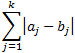

###### Euclidean Distance

<font size=4><center>sqrt(sum((x - y)^2))<center></font>

In [113]:
# K Nearest Neighbors hyperparameters
knn_hyperparameters = {'p': [1, 2, 3, 4, 5],
                      'n_neighbors': list(range(1,30)),
                      'metric': ["euclidean", "cityblock"]
                      }

#### Multinomial Naive Bayes Hyperparameters

* alpha     --> Additive (Laplace/Lidstone) smoothing parameter (0 for no smoothing).

* fit_prior --> Whether to learn class prior probabilities or not. If false, a uniform prior will be used.

In [114]:
# Multinomial Naive Bayes Hyperparameters
mnb_hyperparameters = { 'alpha': np.linspace(0.5, 1.5, 6),
                       'fit_prior': [True, False]    
                        }

#### Gaussian Naive Bayes Hyperparameters

* fit_prior --> Whether to learn class prior probabilities or not. If false, a uniform prior will be used.

#### Binomial Naive Bayes Hyperparameters

* alpha     --> Additive (Laplace/Lidstone) smoothing parameter (0 for no smoothing).

* fit_prior --> Whether to learn class prior probabilities or not. If false, a uniform prior will be used.

In [115]:
bnb_hyperpaeters = {'alpha': np.linspace(0.5, 1.5, 6),
                       'fit_prior': [True, False] 
                   }

#### Hyperparameters Dictionary

* Hyperparameter Dictionary going to be passed as Parameter to GridSearchCV
* It simplifies in applying hyperparameters to all the respective algorithms in GridSearchCV

In [116]:
# Create hyperparameters dictionary
hyperparameters = { 
           'lgl2': lgl2_hyperparameters, 
           'rfc': rfc_hyperparameters, 
           'gbc': gbc_hyperparameters,
           'dtc': dtc_hyperparameters,
           'mnb': mnb_hyperparameters,
           'bnb': bnb_hyperpaeters,
           'gnb': {}
          }

<hr style='height:10px'>

<br id='fit'>

### Training / Fitting

* Import GridSearchCV for Cross Validation
* Create a dictionary to store fitted models - fitted_models
* Loop pipeline_dict to get Pipeline and Name of Algorithms to feed GridSearchCV
* Fit the Model with X_train and y_train
* Store the Model in fitted_models dictionary
* Print once the model been fitted and stored in fitted_models dictionary
* Check the availability of all the Cross-Validation Objects
* Check All the Algorithms are fitted

In [117]:
from sklearn.model_selection import GridSearchCV

In [118]:
fitted_models = {}

for name, pipeline in pipeline_dict.items():

    model = GridSearchCV(pipeline, hyperparameters[name], cv=10, n_jobs=-1)
    
    model.fit(X_train, y_train)
    
    fitted_models[name] = model
    
    print(name, 'has been fitted.')

lgl2 has been fitted.
rfc has been fitted.
gbc has been fitted.
dtc has been fitted.
mnb has been fitted.
gnb has been fitted.
bnb has been fitted.


<hr style='height:10px'>

<br id='eval'>

## EVALUATE MODELS

### Predict Values by Best Score & Accuracy Score of Fitted Models

In [119]:
pred = {}
for name, model in fitted_models.items():
    pred[name] = fitted_models[name].predict(X_test)

#### Display first 10 predictions

In [120]:
for key, val in pred.items():
    print('First 10 {} predicted values are {}'.format(key, pred[key][:10]))

First 10 lgl2 predicted values are [ 6 10  6  7  9  5  7  1  1  2]
First 10 rfc predicted values are [ 2 10  1  3  9  6  8  2  6  2]
First 10 gbc predicted values are [ 2 10  1  3  9  5  8  6  6  2]
First 10 dtc predicted values are [ 2 10  1  3  9  5  7  2  6  1]
First 10 mnb predicted values are [ 6 10  1  2  2  2 10  4  5  2]
First 10 gnb predicted values are [ 6 10  5  3  3  5  7  6  6  2]
First 10 bnb predicted values are [5 4 1 5 9 5 7 1 1 5]


### Accuracy Score

In [121]:
from sklearn.metrics import accuracy_score

In [122]:
final_dict['model_score'] = []
i = 0
for key, val in pred.items():
    acc_score = accuracy_score(y_test, pred[key])
    print('{} accuracy score is {}'.format(key, acc_score))
    final_dict['model_score'].append((i, key, acc_score))
    i += 1

lgl2 accuracy score is 0.7525757575757576
rfc accuracy score is 0.8443939393939394
gbc accuracy score is 0.8575757575757575
dtc accuracy score is 0.826969696969697
mnb accuracy score is 0.3040909090909091
gnb accuracy score is 0.4443939393939394
bnb accuracy score is 0.3424242424242424


### Confusion Matrix

In [123]:
# Import confusion_matrix
from sklearn.metrics import confusion_matrix

In [124]:
# Display confusion matrix for y_test and pred
for key, val in pred.items():
    print ('{} confusion matrix is \n{}\n'.format(key, confusion_matrix(y_test, pred[key])))

lgl2 confusion matrix is 
[[  9   0   0   0   2   0   0   0   0   2   0   2   0]
 [  0 297 175   0   3  17 116   0   0   0   0   0   0]
 [  0  61 450   0   0   0  79   0   0   0   0   0   0]
 [  0   1   5 507   1   3   0  43   6   0  15   5   0]
 [  0   2   0   0 550   6   2   0   0   0   0   3   0]
 [  0   0   0   1   0 611   1   0   0   0   0   6   0]
 [  0 113  91   0   0  31 386   0   0   0   0   0   0]
 [  0   1   8  61   0   0   3 218 295   0   0   6   0]
 [  0   0   3  64   0   0   0 186 338   0   0   6   0]
 [  0   0   0   0   0   0   0   0   0 533   0  93   0]
 [  0   0   0  46   2   0   1   7   0   1 524  10   0]
 [  1   0   3   0   2   0   0  26   6   9   0 544   0]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0]]

rfc confusion matrix is 
[[ 13   0   0   0   0   0   0   0   0   1   0   1   0]
 [  0 383 154   0   1   4  66   0   0   0   0   0   0]
 [  0  59 466   0   0   0  65   0   0   0   0   0   0]
 [  0   0   2 581   0   0   0   1   2   0   0   0   0]
 [  0   2   

## Classification Report

In [125]:
from sklearn.metrics import classification_report

In [126]:
for key, val in pred.items():
    print('\n{} classification report is: \n {}'.format(key, classification_report(y_test, pred[key])))
    print('---------------------------------------------------------------------------------------------')


lgl2 classification report is: 
               precision    recall  f1-score   support

           0       0.90      0.60      0.72        15
           1       0.63      0.49      0.55       608
           2       0.61      0.76      0.68       590
           3       0.75      0.87      0.80       586
           4       0.98      0.98      0.98       563
           5       0.91      0.99      0.95       619
           6       0.66      0.62      0.64       621
           7       0.45      0.37      0.41       592
           8       0.52      0.57      0.54       597
           9       0.98      0.85      0.91       626
          10       0.97      0.89      0.93       591
          11       0.80      0.92      0.86       591
          12       0.00      0.00      0.00         1

    accuracy                           0.75      6600
   macro avg       0.71      0.68      0.69      6600
weighted avg       0.75      0.75      0.75      6600

---------------------------------------------

<hr style='height:10px'>

<br id='finalmodel'>

## Best Estimator & Tuned Parameters

In [127]:
best_model = final_dict['model_score'][max(final_dict['model_score'], key = lambda i : i[2])[0]][1]

### Save the Model

In [128]:
import pickle

In [129]:
final_dict['model'] = fitted_models[best_model].best_estimator_

In [130]:
with open('./models/'+pickle_name + '.pkl', 'wb') as f:
    pickle.dump(final_dict, f)

In [131]:
fitted_models[best_model].best_estimator_

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(max_depth=5, n_estimators=200,
                                            random_state=123))])

<hr style='height:10px'>